![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Proyecto 2 - Clasificación de género de películas

El propósito de este proyecto es que puedan poner en práctica, en sus respectivos grupos de trabajo, sus conocimientos sobre técnicas de preprocesamiento, modelos predictivos de NLP, y la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 2: Clasificación de género de películas"

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 8. Sin embargo, es importante que avancen en la semana 7 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 8, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/t/29c44fce98c747f2a1dfdaf29d4c4965).

## Datos para la predicción de género en películas

![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/moviegenre.png)

En este proyecto se usará un conjunto de datos de géneros de películas. Cada observación contiene el título de una película, su año de lanzamiento, la sinopsis o plot de la película (resumen de la trama) y los géneros a los que pertenece (una película puede pertenercer a más de un género). Por ejemplo:
- Título: 'How to Be a Serial Killer'
- Plot: 'A serial killer decides to teach the secrets of his satisfying career to a video store clerk.'
- Generos: 'Comedy', 'Crime', 'Horror'

La idea es que usen estos datos para predecir la probabilidad de que una película pertenezca, dada la sinopsis, a cada uno de los géneros.

Agradecemos al profesor Fabio González, Ph.D. y a su alumno John Arevalo por proporcionar este conjunto de datos. Ver https://arxiv.org/abs/1702.01992

## Ejemplo predicción conjunto de test para envío a Kaggle
En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [5]:
dataTraining.shape

(7895, 5)

In [6]:
# Visualización datos de test
dataTesting.tail()

,year,title,plot
11263,2008,The Fifth Commandment,"in bangkok , an assassin who turns down a job..."
11265,2003,Coffee and Cigarettes,eleven separate vignettes are presented . in ...
11269,1957,Pal Joey,"joey evans is charming , handsome , funny , ..."
11270,2002,Jonah: A VeggieTales Movie,when the singing veggies encounter some car tr...
11275,1993,Man's Best Friend,a genetically mutated dog is stolen from the l...


In [7]:
# Definición de variables predictoras (X)
vect = CountVectorizer(max_features=1000)
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

(7895, 1000)

In [8]:
# Definición de variable de interés (y)
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))  #evalua el string de generos y lo convierte en lista
le = MultiLabelBinarizer()  #convierte los labels de genero en un matriz binaria
y_genres = le.fit_transform(dataTraining['genres'])

In [9]:
y_genres[:3]

array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0]])

In [10]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

In [11]:
# Definición y entrenamiento
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))
clf.fit(X_train, y_train_genres)

OneVsRestClassifier(estimator=RandomForestClassifier(max_depth=10, n_jobs=-1,
                                                     random_state=42))

In [12]:
# Predicción del modelo de clasificación
y_pred_genres = clf.predict_proba(X_test)

# Impresión del desempeño del modelo
roc_auc_score(y_test_genres, y_pred_genres, average='macro')

np.float64(0.7717668029296991)

In [13]:
y_pred_genres[0]  #probabilidad de ser cada genero

array([0.12940801, 0.09574199, 0.02356309, 0.04346031, 0.31063411,
       0.13620513, 0.17286682, 0.53903876, 0.10271003, 0.06449637,
       0.01038705, 0.02745799, 0.1025892 , 0.03443693, 0.02434172,
       0.06382191, 0.00056747, 0.15334399, 0.06320185, 0.01255809,
       0.0230732 , 0.21804265, 0.02322769, 0.01825165])

In [14]:
# transformación variables predictoras X del conjunto de test
X_test_dtm = vect.transform(dataTesting['plot'])

cols = ['p_Action', 'p_Adventure', 'p_Animation', 'p_Biography', 'p_Comedy', 'p_Crime', 'p_Documentary', 'p_Drama', 'p_Family',
        'p_Fantasy', 'p_Film-Noir', 'p_History', 'p_Horror', 'p_Music', 'p_Musical', 'p_Mystery', 'p_News', 'p_Romance',
        'p_Sci-Fi', 'p_Short', 'p_Sport', 'p_Thriller', 'p_War', 'p_Western']

# Predicción del conjunto de test
y_pred_test_genres = clf.predict_proba(X_test_dtm)

In [15]:
y_pred_test_genres[0]  #prediccion de cada pelicula del conjunto data Testing

array([1.15316340e-01, 1.12544560e-01, 2.16318591e-02, 3.08260443e-02,
       3.96257169e-01, 1.16158054e-01, 6.20356106e-02, 4.95677169e-01,
       6.66169535e-02, 1.04481509e-01, 1.07301694e-02, 2.20083643e-02,
       9.41144900e-02, 7.42213441e-02, 2.51483888e-02, 9.78375203e-02,
       1.02986612e-05, 3.92607621e-01, 6.49677914e-02, 1.19436171e-02,
       1.81223810e-02, 2.03968925e-01, 2.21457537e-02, 1.96686662e-02])

In [30]:
# Guardar predicciones en formato exigido en la competencia de kaggle
res = pd.DataFrame(y_pred_test_genres, index=dataTesting.index, columns=cols)
res.to_csv('pred_genres_text_RF.csv', index_label='ID')
res.head()

,p_Action,p_Adventure,p_Animation,p_Biography,p_Comedy,p_Crime,p_Documentary,p_Drama,p_Family,p_Fantasy,...,p_Musical,p_Mystery,p_News,p_Romance,p_Sci-Fi,p_Short,p_Sport,p_Thriller,p_War,p_Western
1,0.115316,0.112545,0.021632,0.030826,0.396257,0.116158,0.062036,0.495677,0.066617,0.104482,...,0.025148,0.097838,0.000010,0.392608,0.064968,0.011944,0.018122,0.203969,0.022146,0.019669
4,0.133081,0.087854,0.023964,0.070760,0.343026,0.202546,0.099520,0.511076,0.063784,0.062972,...,0.024627,0.061687,0.002156,0.147331,0.059040,0.012346,0.019008,0.199905,0.040175,0.020344
5,0.158209,0.140732,0.018376,0.067342,0.340637,0.469086,0.006762,0.604303,0.088218,0.103984,...,0.022971,0.334849,0.000000,0.387805,0.112995,0.015059,0.022805,0.392327,0.067718,0.018431
6,0.165241,0.139772,0.027845,0.093197,0.333114,0.146278,0.020983,0.591203,0.076191,0.068679,...,0.111233,0.117495,0.010000,0.186832,0.099408,0.001430,0.038273,0.290187,0.079881,0.018423
7,0.165107,0.177139,0.046025,0.031550,0.317075,0.213078,0.028251,0.463566,0.077800,0.139171,...,0.024349,0.076296,0.000000,0.184966,0.266775,0.004899,0.020132,0.229698,0.023483,0.016585


## 2. Generacion de un baseline

### 1. Limpieza y TfidfVectorizer

In [16]:
dataTraining['plot']

3107    most is the story of a single father who takes...
900     a serial killer decides to teach the secrets o...
6724    in sweden ,  a female blackmailer with a disfi...
4704    in a friday afternoon in new york ,  the presi...
2582    in los angeles ,  the editor of a publishing h...
                              ...                        
8417    " our marriage ,  their wedding .  "  it ' s l...
1592    the wandering barbarian ,  conan ,  alongside ...
1723    like a tale spun by scheherazade ,  kismet fol...
7605    mrs .  brisby ,  a widowed mouse ,  lives in a...
215     tinker bell journey far north of never land to...
Name: plot, Length: 7895, dtype: object

In [17]:
import re
def clean_text(text):
    text = text.lower()
    # eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text)
    return text.strip() # eliminar espacios al inicio/final

In [18]:
dataTraining['plot_clean'] = dataTraining['plot'].map(lambda x: clean_text(x))  #limpieza y normalizacion
dataTraining['plot_clean']

3107    most is the story of a single father who takes...
900     a serial killer decides to teach the secrets o...
6724    in sweden , a female blackmailer with a disfig...
4704    in a friday afternoon in new york , the presid...
2582    in los angeles , the editor of a publishing ho...
                              ...                        
8417    " our marriage , their wedding . " it ' s less...
1592    the wandering barbarian , conan , alongside hi...
1723    like a tale spun by scheherazade , kismet foll...
7605    mrs . brisby , a widowed mouse , lives in a ci...
215     tinker bell journey far north of never land to...
Name: plot_clean, Length: 7895, dtype: object

In [19]:
X = dataTraining['plot_clean']

In [21]:
dataTesting['plot'] = dataTesting['plot'].map(lambda x: clean_text(x))  #limpieza y normalizacion

*OJO: SEPARAR TRAIN Y TEST PRIMERO PARA EVITAR LEAKAGE*

In [22]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usando la función train_test_split
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X, y_genres, test_size=0.33, random_state=42)

TfidfVectorizer

In [23]:
#definicion de variable X
from sklearn.feature_extraction.text import TfidfVectorizer

vect_TFIDF = TfidfVectorizer(
    ngram_range=(1,3),  #trigramas
    max_features=50000
)
X_train_tfidf = vect_TFIDF.fit_transform(X_train)
X_test_tfidf = vect_TFIDF.transform(X_test)
X_train_tfidf.shape
#X_test_tfidf.shape

(5289, 50000)

In [24]:
#entrenar el modelo
from sklearn.linear_model import LogisticRegression

clf_LR = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, solver='lbfgs')
)

clf_LR.fit(X_train_tfidf, y_train_genres)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [25]:
# Predicción del modelo de clasificación
y_pred_LR = clf_LR.predict_proba(X_test_tfidf)

# Impresión del desempeño del modelo
roc_auc_score(y_test_genres, y_pred_LR, average='macro')  #0.8654 con bigrama

np.float64(0.8673466766570227)

In [26]:
# transformación variables predictoras X del conjunto de TEST
X_test_TFIDF = vect_TFIDF.transform(dataTesting['plot'])
# Predicción del conjunto de test
y_pred_test_LR = clf_LR.predict_proba(X_test_TFIDF)

In [27]:
y_pred_test_LR[0]

array([0.10748527, 0.09062329, 0.02417129, 0.03282914, 0.45655631,
       0.11720655, 0.02861781, 0.52478042, 0.05486453, 0.09821978,
       0.0203794 , 0.0253292 , 0.07285336, 0.03567187, 0.04559173,
       0.07398757, 0.00067091, 0.65882453, 0.04676873, 0.01049824,
       0.02080907, 0.16997086, 0.02976125, 0.02386814])

In [28]:
#se pueden sacar los nombres de columnas asi
le.classes_

array(['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir',
       'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News',
       'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War',
       'Western'], dtype=object)

In [58]:
# Guardar predicciones en formato exigido en la competencia de kaggle
res = pd.DataFrame(y_pred_test_LR, index=dataTesting.index, columns=cols)
res.to_csv('y_pred_test_LR.csv', index_label='ID')
res.head()

,p_Action,p_Adventure,p_Animation,p_Biography,p_Comedy,p_Crime,p_Documentary,p_Drama,p_Family,p_Fantasy,...,p_Musical,p_Mystery,p_News,p_Romance,p_Sci-Fi,p_Short,p_Sport,p_Thriller,p_War,p_Western
1,0.107485,0.090623,0.024171,0.032829,0.456556,0.117207,0.028618,0.524780,0.054865,0.098220,...,0.045592,0.073988,0.000671,0.658825,0.046769,0.010498,0.020809,0.169971,0.029761,0.023868
4,0.143168,0.065518,0.027111,0.134027,0.286206,0.244849,0.073785,0.728738,0.046369,0.042300,...,0.026789,0.052382,0.000730,0.118254,0.036721,0.012811,0.030465,0.209716,0.055304,0.026344
5,0.123392,0.075090,0.020968,0.056632,0.187428,0.499704,0.025669,0.742298,0.046012,0.061737,...,0.024740,0.359783,0.000617,0.152980,0.077544,0.009333,0.035386,0.484347,0.046084,0.027838
6,0.193102,0.144406,0.020881,0.035587,0.284730,0.138113,0.023847,0.617371,0.062100,0.066961,...,0.032990,0.085300,0.000634,0.262017,0.105458,0.008559,0.032891,0.323389,0.060960,0.033312
7,0.079068,0.081895,0.026163,0.039657,0.226244,0.151396,0.034428,0.518590,0.062627,0.123058,...,0.027398,0.131045,0.000652,0.220646,0.186945,0.010240,0.021588,0.301624,0.030126,0.023007


### 1. TfidfVectorizer con lematizacion

In [61]:
from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JohnM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\JohnM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [67]:
pip install spacy

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 2.9 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/14.2 MB 3.3 MB/s eta 0:00:04
   ------- -------------------------------- 2.6/14.2 MB 4.3 MB/s eta 0:00:03
   -------------- ------------------------- 5.2/14.2 MB 6.6 MB/s eta 0:00:02
   ------------------------------------ --- 12.8/14.2 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 13.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/650.8 kB ? eta -:--:--
   --------------------------------------- 650.8/650.8 kB 39.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 49.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 57.2 MB/s eta 0:00:00

   -----------------

In [69]:
#instalar modelo ingles
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------- ------------ 8.9/12.8 MB 47.0 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 38.4 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


Se valñdará si la eliminacion de puntuacion y reduccion de palabras ayuda

In [30]:
import spacy
nlp = spacy.load("en_core_web_sm")

#funcion de lematiz<acion
def lemmatize_text(text):    
    doc = nlp(text)    
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_punct
        and not token.is_space
    ]    
    return " ".join(tokens)

In [31]:
dataTraining['plot_lemma'] = dataTraining['plot_clean'].map(lemmatize_text)
dataTraining['plot_lemma']

3107    most be the story of a single father who take ...
900     a serial killer decide to teach the secret of ...
6724    in sweden a female blackmailer with a disfigur...
4704    in a friday afternoon in new york the presiden...
2582    in los angeles the editor of a publishing hous...
                              ...                        
8417    our marriage their wedding it s lesson number ...
1592    the wandering barbarian conan alongside his go...
1723    like a tale spin by scheherazade kismet follow...
7605    mrs brisby a widow mouse live in a cinder bloc...
215     tinker bell journey far north of never land to...
Name: plot_lemma, Length: 7895, dtype: object

In [32]:
dataTesting['plot_clean'] = dataTesting['plot'].map(lambda x: clean_text(x))  #limpieza y normalizacion
dataTesting['plot_lemma'] = dataTesting['plot_clean'].map(lemmatize_text)

In [33]:
X = dataTraining['plot_lemma']

In [34]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usando la función train_test_split
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X, y_genres, test_size=0.33, random_state=42)

In [35]:
#definicion de variable X
from sklearn.feature_extraction.text import TfidfVectorizer

vect_TFIDF = TfidfVectorizer(
    ngram_range=(1,3),  #trigramas
    max_features=50000,
    min_df=3, max_df=0.85  #ajuste
)
X_train_tfidf = vect_TFIDF.fit_transform(X_train)
X_test_tfidf = vect_TFIDF.transform(X_test)
X_train_tfidf.shape
#X_test_tfidf.shape

(5289, 50000)

In [36]:
#entrenar el modelo
from sklearn.linear_model import LogisticRegression

clf_LR = OneVsRestClassifier(
    LogisticRegression(C=2, max_iter=1000, solver='lbfgs') #C: controlar regularizacion
)

clf_LR.fit(X_train_tfidf, y_train_genres)

OneVsRestClassifier(estimator=LogisticRegression(C=2, max_iter=1000))

In [37]:
# Predicción del modelo de clasificación
y_pred_LR = clf_LR.predict_proba(X_test_tfidf)

# Impresión del desempeño del modelo
roc_auc_score(y_test_genres, y_pred_LR, average='macro')  #0.8654 con bigrama

np.float64(0.8784395283515759)

Mejora la generalizacion 

### SVC

In [40]:
#entrenar el modelo
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svc = LinearSVC(C=0.1, penalty ='l2')
clf_svc = OneVsRestClassifier(
    CalibratedClassifierCV(svc)
)
clf_svc.fit(X_train_tfidf, y_train_genres)

y_pred_svc = clf_svc.predict_proba(X_test_tfidf)

# Impresión del desempeño del modelo
roc_auc_score(y_test_genres, y_pred_svc, average='macro')

np.float64(0.8797898902658599)

In [43]:
# transformación variables predictoras X del conjunto de TEST
X_test_TFIDF = vect_TFIDF.transform(dataTesting['plot_lemma'])
# Predicción del conjunto de test
y_pred_test_SVC = clf_svc.predict_proba(X_test_TFIDF)

In [44]:
# Guardar predicciones en formato exigido en la competencia de kaggle
res = pd.DataFrame(y_pred_test_SVC, index=dataTesting.index, columns=cols)
res.to_csv('y_pred_test_SVC.csv', index_label='ID')
res.head()

,p_Action,p_Adventure,p_Animation,p_Biography,p_Comedy,p_Crime,p_Documentary,p_Drama,p_Family,p_Fantasy,...,p_Musical,p_Mystery,p_News,p_Romance,p_Sci-Fi,p_Short,p_Sport,p_Thriller,p_War,p_Western
1,0.043674,0.034715,0.002878,0.010101,0.458833,0.053102,0.004788,0.606873,0.003625,0.052963,...,0.082946,0.042727,0.001066,0.898987,0.008576,0.003285,0.003081,0.106331,0.006566,0.004635
4,0.133053,0.018034,0.013023,0.603858,0.199709,0.392766,0.030280,0.799770,0.006082,0.006003,...,0.018911,0.016494,0.001477,0.047196,0.004841,0.018237,0.009345,0.172307,0.049880,0.009891
5,0.044027,0.013508,0.001656,0.031575,0.104208,0.919048,0.001832,0.869811,0.003450,0.010965,...,0.009077,0.816916,0.000784,0.127326,0.032589,0.001039,0.009446,0.789060,0.013729,0.004192
6,0.118433,0.061753,0.002009,0.027437,0.189973,0.060321,0.002578,0.731992,0.009326,0.014089,...,0.025544,0.044646,0.001328,0.266662,0.033928,0.001605,0.012198,0.388461,0.062750,0.006788
7,0.015801,0.020516,0.007419,0.016981,0.139599,0.052333,0.005938,0.394997,0.012901,0.197303,...,0.008176,0.178966,0.001040,0.176319,0.842142,0.003147,0.002228,0.280148,0.002329,0.002347


### Redes Neuronales

In [50]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   -- ------------------------------------- 17.6/351.2 MB 85.7 MB/s eta 0:00:04
   ---- ----------------------------------- 35.1/351.2 MB 83.4 MB/s eta 0:00:04
   ------ --------------------------------- 55.6/351.2 MB 88.1 MB/s eta 0:00:04
   -------- ------------------------------- 76.5/351.2 MB 91.5 MB/s eta 0:00:04
   ----------- ---------------------------- 98.0/351.2 MB 94.3 MB/s eta 0:00:03
   ------------- ------------------------- 120.8/351.2 MB 96.4 MB/s eta 0:00:03
   --------------- ----------------------- 142.9/351.2 MB 98.0 MB/s eta 0:00:03
   ------------------ -------------------- 164.6/351.2 MB 99.0 MB/s eta 0:00:02
   -------------------- ----------------- 187.4/351.2 MB 100.4 MB/s eta 0:00:02
   ---------------------- ---------------- 205.8/351.2 MB 99.1 MB/s eta 0:00:02
   ------------------------- ------------- 225.2/351.2 MB 98.4 MB/s eta 0:00:02
   --------------------------- ----------- 245.9/

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [46]:
#convertir a lista
X = dataTraining['plot_clean'].tolist()

In [84]:
# Definición de vocabulario: para cada caracter existente le defino posicion o ID
import numpy as np
import keras
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words = 20000) #dataset mediano
tokenizer.fit_on_texts(X)

In [85]:
tokenizer.word_index

{'the': 1,
 'to': 2,
 'and': 3,
 'a': 4,
 'of': 5,
 'in': 6,
 'is': 7,
 'his': 8,
 "'": 9,
 'he': 10,
 's': 11,
 'with': 12,
 'her': 13,
 'that': 14,
 'for': 15,
 'who': 16,
 'on': 17,
 'as': 18,
 'they': 19,
 'she': 20,
 'by': 21,
 'but': 22,
 'has': 23,
 'their': 24,
 'an': 25,
 'him': 26,
 'when': 27,
 'from': 28,
 'are': 29,
 'it': 30,
 'n': 31,
 'at': 32,
 'be': 33,
 'one': 34,
 'out': 35,
 'life': 36,
 'not': 37,
 'up': 38,
 'have': 39,
 'after': 40,
 'will': 41,
 'into': 42,
 'new': 43,
 'this': 44,
 'them': 45,
 'which': 46,
 'all': 47,
 'was': 48,
 'man': 49,
 'about': 50,
 'can': 51,
 'what': 52,
 't': 53,
 'two': 54,
 'get': 55,
 'only': 56,
 'family': 57,
 'other': 58,
 'so': 59,
 'while': 60,
 'love': 61,
 'find': 62,
 'father': 63,
 'time': 64,
 'where': 65,
 'young': 66,
 'being': 67,
 'more': 68,
 'also': 69,
 'old': 70,
 'been': 71,
 'finds': 72,
 'world': 73,
 'back': 74,
 'own': 75,
 'years': 76,
 'friend': 77,
 'now': 78,
 'wife': 79,
 'there': 80,
 'or': 81,
 'home

In [86]:
X_seq = tokenizer.texts_to_sequences(X)
X_seq

[[133,
  7,
  1,
  108,
  5,
  4,
  643,
  63,
  16,
  138,
  8,
  1064,
  114,
  70,
  109,
  2,
  123,
  12,
  26,
  32,
  1,
  3389,
  18262,
  65,
  10,
  7,
  1,
  2540,
  7872,
  4,
  102,
  110,
  1,
  186,
  124,
  4,
  105,
  2812,
  4,
  423,
  4,
  294,
  12862,
  32,
  1,
  2540,
  1,
  63,
  129,
  42,
  1,
  4908,
  379,
  3,
  155,
  8,
  109,
  2,
  360,
  32,
  1,
  2121,
  5,
  1,
  1317,
  1318,
  4,
  430,
  172,
  3,
  1,
  2540,
  7,
  11288,
  466,
  30,
  7,
  1407,
  2,
  930,
  25,
  1867,
  165,
  1,
  423,
  685,
  2,
  930,
  1,
  109,
  220,
  44,
  3,
  150,
  2,
  4188,
  8,
  63,
  16,
  7,
  37,
  256,
  2,
  181,
  44,
  100,
  18,
  1,
  10127,
  423,
  2541,
  8,
  109,
  244,
  42,
  1,
  18262,
  6909,
  272,
  60,
  2974,
  2,
  3296,
  1,
  2540,
  564,
  1,
  63,
  12,
  4,
  2884,
  1090,
  1,
  63,
  95,
  14988,
  1,
  2540,
  1,
  14989,
  6910,
  1,
  186,
  1,
  116,
  6,
  1,
  423,
  29,
  1248,
  6911,
  2,
  1,
  555,
  4,
  186,
  60

In [87]:
#secuencias 
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 300
X_pad = pad_sequences(
    X_seq,
    maxlen=max_len,
    padding='post'
)

In [88]:
# Separación de variables predictoras (X_pad) y variable de interés (y) en set de entrenamiento y test usando la función train_test_split
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_pad, y_genres, test_size=0.33, random_state=42)

In [89]:
len(tokenizer.word_index)

38705

In [62]:
!pip install livelossplot

In [107]:
y_genres.shape

(7895, 24)

**LA CREACION DE LA RED SE DEBE HACER MULTICAPA:**

In [99]:
# Definición red neuronal con la función Sequential()
import numpy as np
import keras
from keras import backend as K
from keras.models import Sequential
#from keras.layers.recurrent import LSTM
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN
#from keras.layers.core import Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
#from keras.layers.embeddings import Embedding
from keras.layers import Embedding
from keras.preprocessing import sequence
from livelossplot import PlotLossesKeras
%matplotlib inline

model = Sequential()
# Definición de la capa embedding: convierte palabras (o tokens) en vectores numéricos densos que la red puede entender.
# Embedding(input_dim=10000, output_dim=128), input_dim=longitud vocabulario
    #output_dim: tamaño del vector embedding
model.add(Embedding(len(tokenizer.word_index) + 1, 128, input_length=max_len))
# Definición de la capa recurrente LSTM
model.add(LSTM(128))  #se canmbia de 32 a 128
model.add(Dense(64, activation='relu'))
# Definición de dropout para evitar overfitting
model.add(Dropout(0.5))
# Definición capa densa con función sigmoide para predicción MULTICAPA
model.add(Dense(y_train_genres.shape[1], activation='sigmoid'))
# Definición de función de perdida.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])

# Impresión de la arquitectura de la red neuronal
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
#definicion de early stopping: Detiene entrenamiento cuando la métrica deja de mejorar.
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_AUC', mode='max', patience=3, restore_best_weights=True)

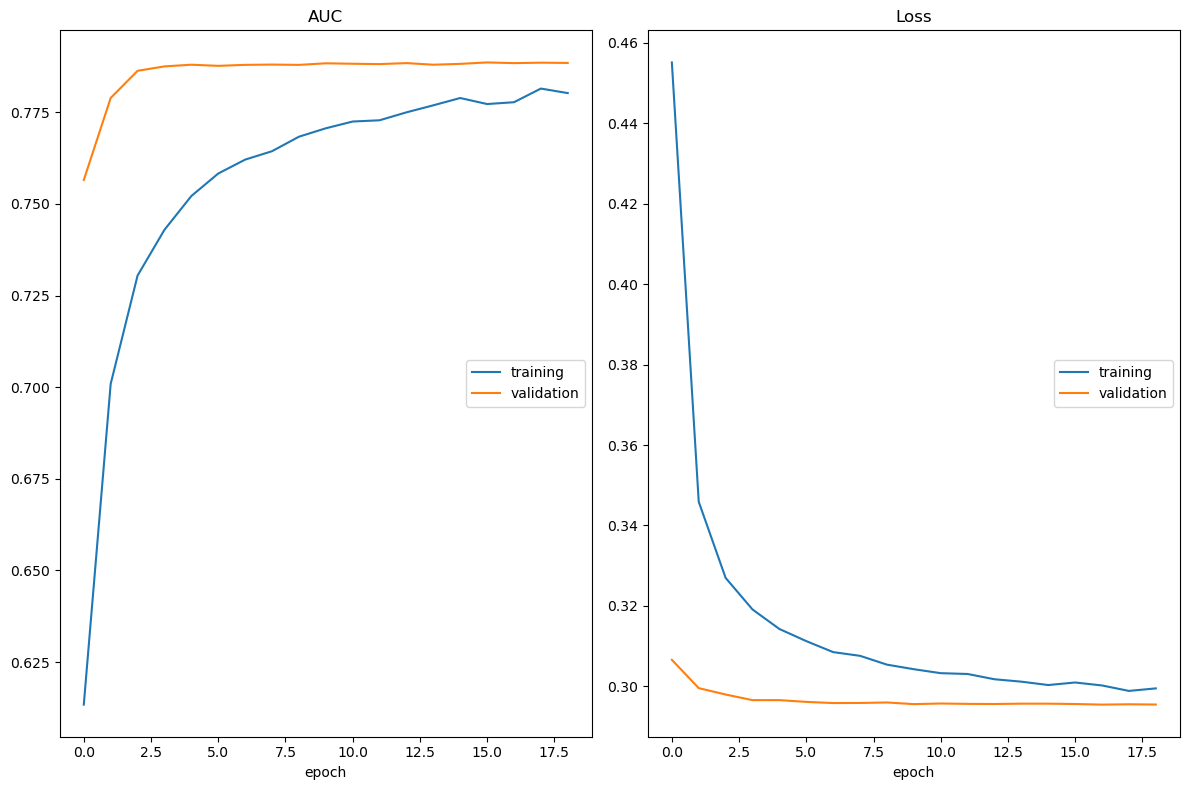

AUC
	training         	 (min:    0.613, max:    0.781, cur:    0.780)
	validation       	 (min:    0.757, max:    0.789, cur:    0.788)
Loss
	training         	 (min:    0.299, max:    0.455, cur:    0.299)
	validation       	 (min:    0.295, max:    0.307, cur:    0.295)
42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - AUC: 0.7802 - loss: 0.2995 - val_AUC: 0.7885 - val_loss: 0.2955


In [101]:
# Entrenamiento de la red neuronal usando el set de entrenamiento
model.fit(X_train, y_train_genres, validation_data=(X_test, y_test_genres), 
          batch_size=128, epochs=30, verbose=1,
          callbacks=[PlotLossesKeras(), early_stop])

In [102]:
y_pred_red = model.predict(X_test) #keras devuelve la salida como probabilidad

# Impresión del desempeño del modelo
roc_auc_score(y_test_genres, y_pred_red)

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step


np.float64(0.4923270631513237)